Signal minimum = -1.0
Signal maximum = 1.0

Bits = 2
Number of levels L = 4
Step size Delta = 0.500000
Minimum index = 0
Maximum index = 3
Index validation: True
PCM word length validation: True
MSE = 0.02619466
Measured SQNR = 12.8076 dB
Theoretical SQNR = 13.8000 dB
First 5 PCM words: ['10', '10', '10', '10', '10']

Bits = 3
Number of levels L = 8
Step size Delta = 0.250000
Minimum index = 0
Maximum index = 7
Index validation: True
PCM word length validation: True
MSE = 0.00616035
Measured SQNR = 19.0936 dB
Theoretical SQNR = 19.8200 dB
First 5 PCM words: ['100', '100', '100', '100', '100']

Bits = 4
Number of levels L = 16
Step size Delta = 0.125000
Minimum index = 0
Maximum index = 15
Index validation: True
PCM word length validation: True
MSE = 0.00147083
Measured SQNR = 25.3141 dB
Theoretical SQNR = 25.8400 dB
First 5 PCM words: ['1000', '1000', '1000', '1000', '1000']

Bits = 6
Number of levels L = 64
Step size Delta = 0.031250
Minimum index = 0
Maximum index = 63
Index validati

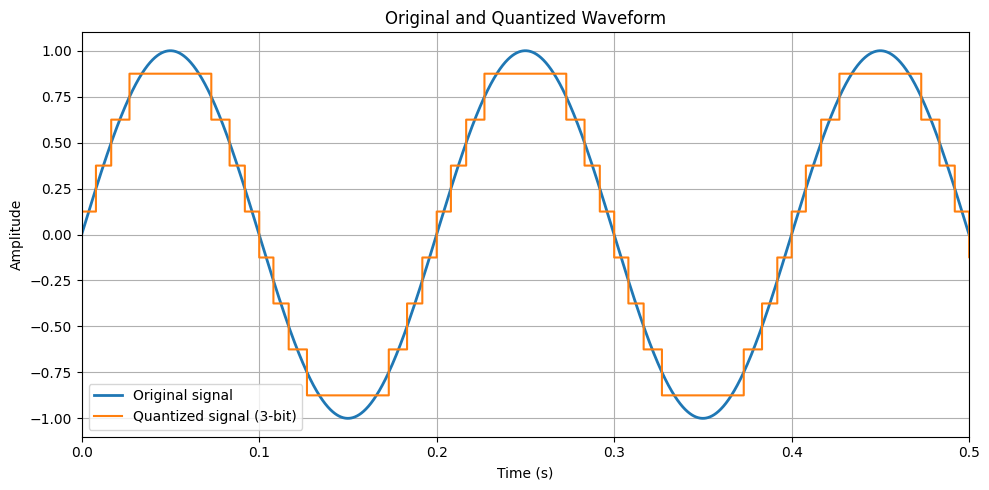

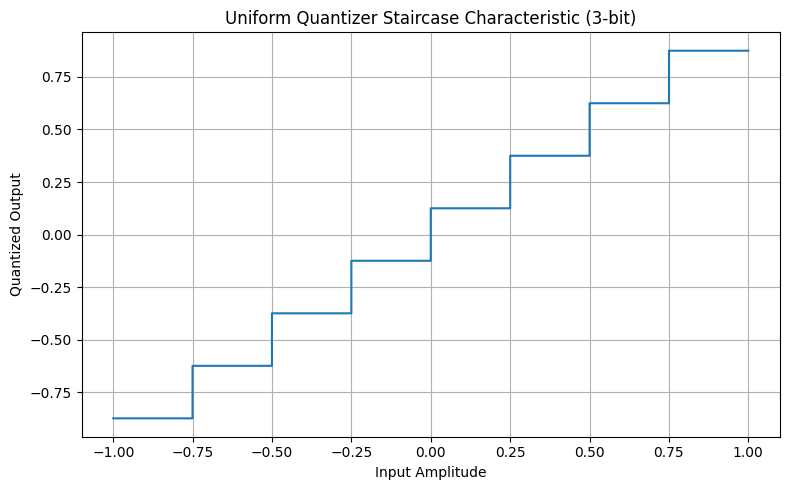

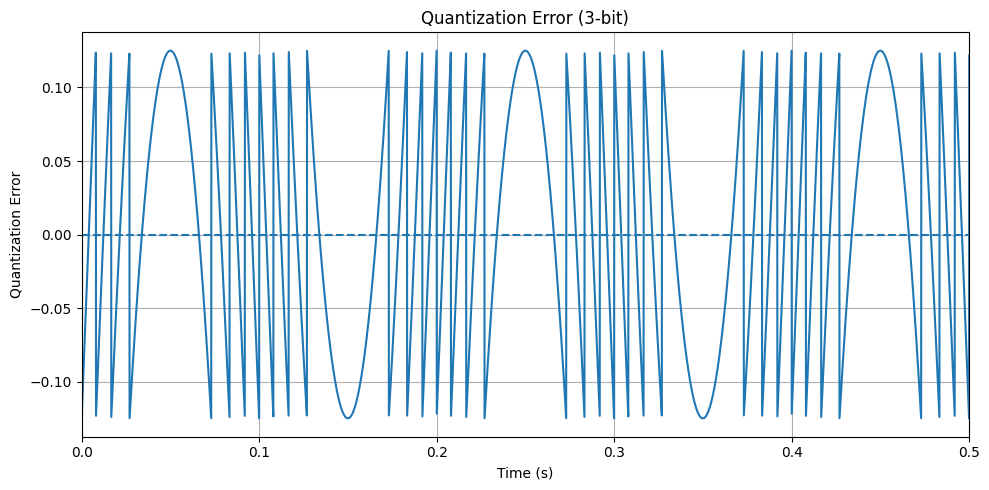

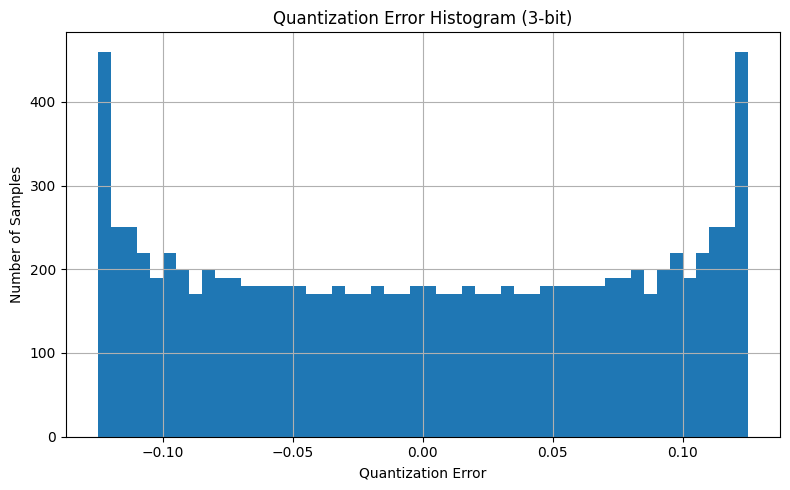

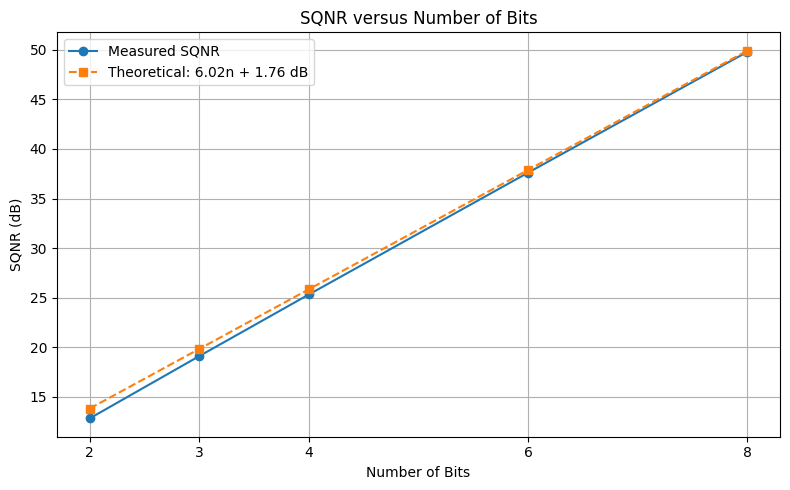



FINAL RESULTS
Bits    Levels    Delta       MSE            Measured SQNR     Theory SQNR    
--------------------------------------------------------------------------------
2       4         0.500000    0.02619466     12.8076           13.8000        
3       8         0.250000    0.00616035     19.0936           19.8200        
4       16        0.125000    0.00147083     25.3141           25.8400        
6       64        0.031250    0.00008677     37.6058           37.8800        
8       256       0.007812    0.00000524     49.7929           49.9200        


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 4 - UNIFORM QUANTIZATION AND PCM
# ============================================================

# ------------------------------------------------------------
# STEP 1: Generate and normalize sinusoidal signal
# ------------------------------------------------------------

fs = 10000              # Sampling frequency
f = 5                   # Signal frequency
duration = 1            # Duration in seconds

t = np.arange(0, duration, 1/fs)

# Original sinusoidal signal
x = np.sin(2 * np.pi * f * t)

# Normalize to [-1, 1]
x = x / np.max(np.abs(x))

print("Signal minimum =", np.min(x))
print("Signal maximum =", np.max(x))


# ------------------------------------------------------------
# STEP 2: Quantizer function
# ------------------------------------------------------------

def uniform_quantizer(x, bits):

    # Number of quantization levels
    L = 2 ** bits

    # Quantization step size
    delta = 2 / L

    # Calculate quantizer index
    indices = np.floor((x + 1) / delta).astype(int)

    # Make sure index remains between 0 and L-1
    indices = np.clip(indices, 0, L - 1)

    # Mid-rise quantization levels
    xq = -1 + (indices + 0.5) * delta

    # Generate binary PCM words
    pcm_words = [
        format(index, f"0{bits}b")
        for index in indices
    ]

    return xq, indices, pcm_words, delta


# ------------------------------------------------------------
# STEP 3: Calculate MSE and SQNR
# ------------------------------------------------------------

def calculate_metrics(x, xq):

    # Quantization error
    error = x - xq

    # Mean Squared Error
    mse = np.mean(error ** 2)

    # Signal power
    signal_power = np.mean(x ** 2)

    # Noise/quantization error power
    error_power = np.mean(error ** 2)

    # SQNR
    sqnr = 10 * np.log10(signal_power / error_power)

    return error, mse, sqnr


# ------------------------------------------------------------
# STEP 4: Test all required bit resolutions
# ------------------------------------------------------------

bits_list = [2, 3, 4, 6, 8]

results = []

for bits in bits_list:

    xq, indices, pcm_words, delta = uniform_quantizer(x, bits)

    error, mse, sqnr = calculate_metrics(x, xq)

    # Theoretical SQNR
    theoretical_sqnr = 6.02 * bits + 1.76

    # --------------------------------------------------------
    # MANDATORY VALIDATION
    # --------------------------------------------------------

    L = 2 ** bits

    # Check index range
    index_valid = (
        np.min(indices) >= 0
        and np.max(indices) <= L - 1
    )

    # Check PCM word length
    word_length_valid = all(
        len(word) == bits
        for word in pcm_words
    )

    print("\n" + "=" * 60)
    print(f"Bits = {bits}")
    print(f"Number of levels L = {L}")
    print(f"Step size Delta = {delta:.6f}")

    print(f"Minimum index = {np.min(indices)}")
    print(f"Maximum index = {np.max(indices)}")

    print("Index validation:", index_valid)
    print("PCM word length validation:", word_length_valid)

    print(f"MSE = {mse:.8f}")
    print(f"Measured SQNR = {sqnr:.4f} dB")
    print(f"Theoretical SQNR = {theoretical_sqnr:.4f} dB")

    # Show first 5 PCM words
    print("First 5 PCM words:", pcm_words[:5])

    results.append([
        bits,
        L,
        delta,
        mse,
        sqnr,
        theoretical_sqnr
    ])


# ------------------------------------------------------------
# STEP 5: Convert results into arrays
# ------------------------------------------------------------

results = np.array(results)

bits_values = results[:, 0]
levels_values = results[:, 1]
delta_values = results[:, 2]
mse_values = results[:, 3]
sqnr_values = results[:, 4]
theoretical_sqnr_values = results[:, 5]


# ============================================================
# GRAPH 1: Original and quantized waveform
# ============================================================

bits = 3

xq, indices, pcm_words, delta = uniform_quantizer(x, bits)

plt.figure(figsize=(10, 5))

plt.plot(
    t,
    x,
    label="Original signal",
    linewidth=2
)

plt.step(
    t,
    xq,
    where="mid",
    label=f"Quantized signal ({bits}-bit)"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Original and Quantized Waveform"
)

plt.xlim(0, 0.5)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 2: Staircase characteristic
# ============================================================

input_values = np.linspace(-1, 1, 2000)

xq_characteristic, _, _, _ = uniform_quantizer(
    input_values,
    bits
)

plt.figure(figsize=(8, 5))

plt.step(
    input_values,
    xq_characteristic,
    where="mid"
)

plt.xlabel("Input Amplitude")
plt.ylabel("Quantized Output")

plt.title(
    f"Uniform Quantizer Staircase Characteristic ({bits}-bit)"
)

plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3: Quantization error waveform
# ============================================================

error = x - xq

plt.figure(figsize=(10, 5))

plt.plot(
    t,
    error
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Quantization Error")

plt.title(
    f"Quantization Error ({bits}-bit)"
)

plt.xlim(0, 0.5)

plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 4: Error histogram
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    error,
    bins=50
)

plt.xlabel("Quantization Error")
plt.ylabel("Number of Samples")

plt.title(
    f"Quantization Error Histogram ({bits}-bit)"
)

plt.grid(True)
plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 5: SQNR versus number of bits
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    bits_values,
    sqnr_values,
    marker="o",
    label="Measured SQNR"
)

plt.plot(
    bits_values,
    theoretical_sqnr_values,
    marker="s",
    linestyle="--",
    label="Theoretical: 6.02n + 1.76 dB"
)

plt.xlabel("Number of Bits")
plt.ylabel("SQNR (dB)")

plt.title(
    "SQNR versus Number of Bits"
)

plt.xticks(bits_list)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# ============================================================
# STEP 6: Final results table
# ============================================================

print("\n")
print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

print(
    f"{'Bits':<8}"
    f"{'Levels':<10}"
    f"{'Delta':<12}"
    f"{'MSE':<15}"
    f"{'Measured SQNR':<18}"
    f"{'Theory SQNR':<15}"
)

print("-" * 80)

for row in results:

    print(
        f"{int(row[0]):<8}"
        f"{int(row[1]):<10}"
        f"{row[2]:<12.6f}"
        f"{row[3]:<15.8f}"
        f"{row[4]:<18.4f}"
        f"{row[5]:<15.4f}"
    )